In [1]:
!pip install transformers -q

In [2]:
!pip install datasets -q

In [3]:
!pip install torch scikit-learn pandas matplotlib seaborn accelerate -q

In [5]:
import pandas as pd
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments, DataCollatorWithPadding
from torch.utils.data import Dataset
import random
import os

device = "cuda" if torch.cuda.is_available() else "cpu"

def seed_everything(seed=322):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

seed_everything(322)

In [6]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

print(f"len train {train_df.shape}")
print(f"len test {test_df.shape}")

len train (173803, 3)
len test (74487, 2)


# Посмотрим на данные

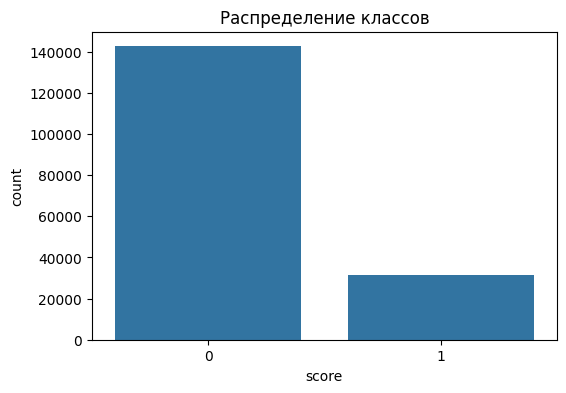

нормисы 82.03%
токсики 17.97%


In [13]:
plt.figure(figsize=(6, 4))
sns.countplot(x='score', data=train_df)
plt.title('Распределение классов')
plt.show()

ratio = train_df['score'].value_counts(normalize=True)

print(f"нормисы {ratio[0]:.2%}")
print(f"токсики {ratio[1]:.2%}")

Я рад что нормисы побеждают! Но я не рад что такой дисбаланс

Посмотрим на распределение длин предложений в токенах

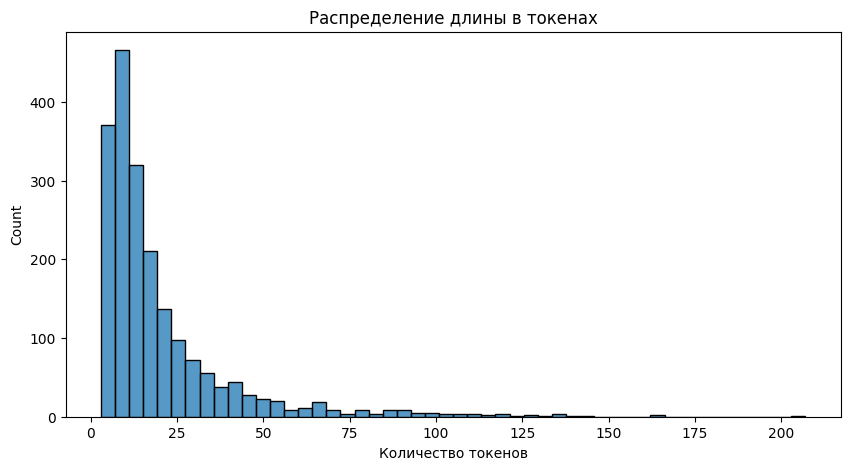

mean len 20.4
max len 207
99 перцентиль 110.0


In [14]:
tmp_tokenizer = AutoTokenizer.from_pretrained("s-nlp/russian_toxicity_classifier")

token_lens = [len(tmp_tokenizer.encode(str(text))) for text in train_df['text'].sample(2000).tolist()]

mean_val = np.mean(token_lens)
max_val = np.max(token_lens)
p99_val = np.percentile(token_lens, 99)

plt.figure(figsize=(10, 5))
sns.histplot(token_lens, bins=50)

plt.title('Распределение длины в токенах')
plt.xlabel('Количество токенов')
plt.show()

print(f"mean len {mean_val:.1f}")
print(f"max len {max_val}")
print(f"99 перцентиль {p99_val:.1f}")

Ну думаю макс длину можно взять как 120. Все основное мы покроем такой длиной

# Выбор модели и обучение

Изначально свой первый эксперимент я делал с rubert-base-cased, собственно с ней я не прошел третий бенчмарк. Я сразу подумал, что ну он там обучался на википедии и не выкупает токсичность. Я был уверен что есть где-то модифицированная версия, обученная на токсичность, ибо в 2024 году было хайп видеть в пост ТГ как кто-то подобное делал. Сразу нашел https://huggingface.co/s-nlp/russian_toxicity_classifier, который юзал данные с 2ch, где конечно же концентрация токсичности. По идее можно было даже взять https://huggingface.co/cointegrated/rubert-tiny2.

In [9]:
MODEL_NAME = "s-nlp/russian_toxicity_classifier"

MAX_LEN = 120

Ну тут ничего интересного

In [10]:
class ToxicityDataset(Dataset):
    def __init__(self, texts, labels=None, tokenizer=None, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, item):
        text = str(self.texts[item])
        encoding = self.tokenizer(
            text,
            truncation=True,
            padding='max_length',
            max_length=self.max_len,
            return_tensors='pt'
        )

        item_dict = {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten()
        }

        if self.labels is not None:
            item_dict['labels'] = torch.tensor(self.labels[item], dtype=torch.long)

        return item_dict

Нам нужна stratify, так как дисбаланс классов!!!

In [11]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

X_train, X_val, y_train, y_val = train_test_split(
    train_df['text'].values,
    train_df['score'].values,
    test_size=0.1,
    random_state=42,
    stratify=train_df['score']
)

In [12]:
train_dataset = ToxicityDataset(X_train, y_train, tokenizer, MAX_LEN)
val_dataset = ToxicityDataset(X_val, y_val, tokenizer, MAX_LEN)
test_dataset = ToxicityDataset(test_df['text'].values, None, tokenizer, MAX_LEN)

Кол во эпох поставил 2, чтобы просто по началу потестить как модель ведет себя (спойлер, больше эпох и не нужно). Батч 128, ибо ну в T4 GPU влезло, почему бы и нет? Learning rate вроде дефолтный из доки по rubert

In [15]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)
model.to(device)

training_args = TrainingArguments(
    output_dir='./results',
    num_train_epochs=2,
    learning_rate=2e-5,
    per_device_train_batch_size=128,
    per_device_eval_batch_size=128,
    fp16=True,
    dataloader_num_workers=2,
    weight_decay=0.01,
    eval_strategy="epoch",
    save_strategy="no",
    logging_dir='./logs',
    report_to="none"
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

trainer.train()

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/711M [00:00<?, ?B/s]

Epoch,Training Loss,Validation Loss
1,0.038700,0.036716
2,0.017100,0.042284


TrainOutput(global_step=2446, training_loss=0.028549239173446244, metrics={'train_runtime': 1490.6603, 'train_samples_per_second': 209.869, 'train_steps_per_second': 1.641, 'total_flos': 1.92920425788384e+16, 'train_loss': 0.028549239173446244, 'epoch': 2.0})

Начал переобучаться на второй эпохе

Отдельно просто решил посмотреть сколько ROC AUC

In [16]:
from sklearn.metrics import roc_auc_score

val_predictions = trainer.predict(val_dataset)

val_logits = torch.tensor(val_predictions.predictions)
val_probs = torch.nn.functional.softmax(val_logits, dim=-1)
val_toxic_probs = val_probs[:, 1].numpy()

val_true_labels = val_predictions.label_ids
score = roc_auc_score(val_true_labels, val_toxic_probs)

print(f"val {score:.5f}")

val 0.99837


Упаковка результатов в csv

In [17]:
predictions = trainer.predict(test_dataset)
logits = torch.tensor(predictions.predictions)

probs = torch.nn.functional.softmax(logits, dim=-1)

toxic_probs = probs[:, 1].numpy()

submission = pd.DataFrame({
    'id': test_df['id'],
    'score': toxic_probs
})

submission.to_csv('submission.csv', index=False)

print(submission.head())

       id     score
0  152591  0.000072
1  108771  0.999655
2  198853  0.000078
3  194736  0.000077
4   88110  0.000137
